# PiToMe vs TDA-PiToMe (FloodComplex) Comparison

This notebook compares the original PiToMe energy-based scoring with TDA-PiToMe's GPU-accelerated FloodComplex persistent homology approach.

In [1]:
# Clone repository
!git clone https://github.com/a11to1n3/PiToMe.git
%cd PiToMe

Cloning into 'PiToMe'...
remote: Enumerating objects: 8072, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 8072 (delta 25), reused 33 (delta 11), pack-reused 8021 (from 2)
Receiving objects: 100% (8072/8072), 179.51 MiB | 22.98 MiB/s, done.
Resolving deltas: 100% (3972/3972), done.
/content/PiToMe


In [13]:
!git checkout feature/tda-pitome
!git pull

Already on 'feature/tda-pitome'
Your branch is up to date with 'origin/feature/tda-pitome'.
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 5 (delta 4), reused 5 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 1.85 KiB | 945.00 KiB/s, done.
From https://github.com/a11to1n3/PiToMe
   2731f52..015e5c1  feature/tda-pitome -> origin/feature/tda-pitome
Updating 2731f52..015e5c1
Fast-forward
 algo/tda-pitome/tda.py | 145 +++++++++++++++++--------------------------------
 1 file changed, 50 insertions(+), 95 deletions(-)


In [3]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 13.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.3/100.3 kB 10.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.9/314.9 kB 28.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 126.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
!pip install gudhi
!pip install salesforce-lavis transformers timm

  Using cached gudhi-3.11.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (1.6 kB)
Using cached gudhi-3.11.0-cp312-cp312-manylinux_2_28_x86_64.whl (4.2 MB)
  Using cached salesforce_lavis-1.0.2-py3-none-any.whl.metadata (18 kB)
  Using cached contexttimer-0.3.3-py3-none-any.whl
  Using cached decord-0.6.0-py3-none-manylinux2010_x86_64.whl.metadata (422 bytes)
  Using cached fairscale-0.4.4-py3-none-any.whl
  Using cached ftfy-6.3.1-py3-none-any.whl.metadata (7.3 kB)
  Using cached iopath-0.1.10-py3-none-any.whl
  Using cached opencv_python_headless-4.5.5.64-cp36-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (18 kB)
  Using cached opendatasets-0.1.22-py3-none-any.whl.metadata (9.2 kB)
  Using cached pre_commit-4.5.0-py2.py3-none-any.whl.metadata (1.2 kB)
  Using cached pycocoevalcap-1.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached python_magic-0.4.27-py2.py3-none-any.whl.metadata (5.8 kB)
  Using cached streamlit-1.52.1-py3-none-any.whl.metadata (9.8 kB)
  Using cac

In [14]:
import torch
import torch.nn.functional as F
import time
import math
import sys
sys.path.insert(0, '.')

print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4


In [15]:
# Load TDA module
import importlib.util
spec = importlib.util.spec_from_file_location('tda', './algo/tda-pitome/tda.py')
tda = importlib.util.module_from_spec(spec)
spec.loader.exec_module(tda)

# Load PiToMe
from algo.pitome.merge import pitome_vision

print('✓ Modules loaded')

✓ Modules loaded


In [16]:
# Test configuration
B, T, C = 4, 196, 768  # Typical DeiT: 4 batches, 196 tokens (14x14), 768 dims
RATIO = 0.7  # Keep 70% of tokens

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(42)

# Simulated token embeddings
x = torch.randn(B, T, C, device=device)
print(f'Input: {x.shape} on {device}')

Input: torch.Size([4, 196, 768]) on cuda


## PiToMe (Energy-Based Scoring)

In [17]:
# PiToMe scoring
x_cpu = x.cpu()

t0 = time.time()
merge_pitome = pitome_vision(metric=x_cpu, ratio=RATIO, class_token=False)
merged = merge_pitome(x_cpu.clone())
pitome_time = (time.time() - t0) * 1000

print(f'PiToMe time: {pitome_time:.2f}ms')
print(f'Output: {merged.shape}')

PiToMe time: 14.71ms
Output: torch.Size([4, 138, 768])


## TDA-PiToMe (FloodComplex GPU)

In [18]:
# FloodComplex scoring
scorer = tda.FloodComplexScorer(
    landmark_fraction=0.1,
    max_filtration_value=2.0,
    n_filtration_steps=50
)

# Warmup
_ = scorer.compute_scores(x[:1])

# Timed run
if device == 'cuda':
    torch.cuda.synchronize()
t0 = time.time()
scores = scorer.compute_scores(x)
if device == 'cuda':
    torch.cuda.synchronize()
flood_time = (time.time() - t0) * 1000

print(f'FloodComplex time: {flood_time:.2f}ms')
print(f'Scores: {scores.shape}, range [{scores.min():.3f}, {scores.max():.3f}]')

FloodComplex time: 12.29ms
Scores: torch.Size([4, 196]), range [0.000, 1.000]


## Comparison

In [19]:
# Compute PiToMe energy scores for correlation
metric = F.normalize(x_cpu, p=2, dim=-1)
sim = metric @ metric.transpose(-1, -2)
energy = F.elu(sim - 0.5, alpha=1.0).mean(dim=-1)
energy = (energy - energy.min()) / (energy.max() - energy.min() + 1e-8)

# Correlation between methods
flood_cpu = scores.cpu()
corr = torch.corrcoef(torch.stack([flood_cpu[0], energy[0]]))[0, 1]

print('='*50)
print('COMPARISON SUMMARY')
print('='*50)
print(f'{"Method":<20} {"Time (ms)":<15} {"Device"}')
print(f'{"PiToMe":<20} {pitome_time:<15.2f} CPU')
print(f'{"TDA-PiToMe":<20} {flood_time:<15.2f} {device.upper()}')
print(f'\nSpeedup: {pitome_time/flood_time:.2f}x')
print(f'Score correlation: {corr:.3f}')

COMPARISON SUMMARY
Method               Time (ms)       Device
PiToMe               14.71           CPU
TDA-PiToMe           12.29           CUDA

Speedup: 1.20x
Score correlation: 0.397


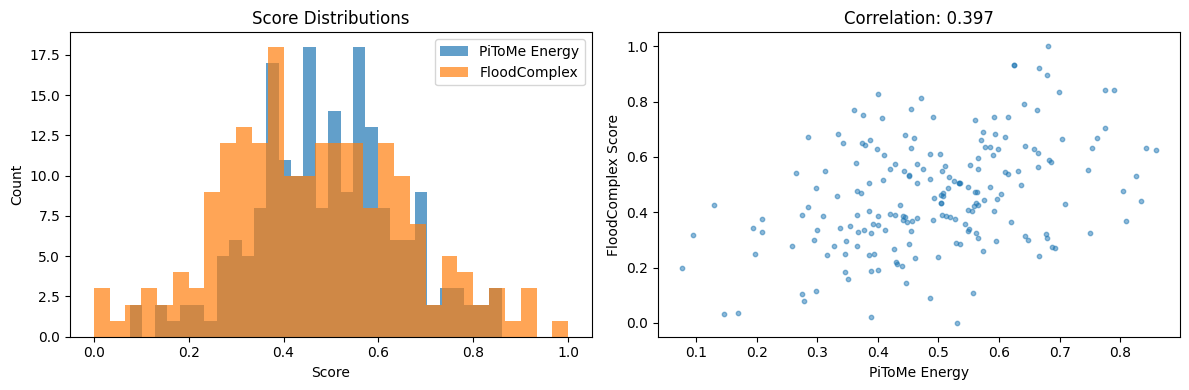

In [20]:
# Visualize score distributions
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(energy[0].numpy(), bins=30, alpha=0.7, label='PiToMe Energy')
axes[0].hist(flood_cpu[0].numpy(), bins=30, alpha=0.7, label='FloodComplex')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].set_title('Score Distributions')

axes[1].scatter(energy[0].numpy(), flood_cpu[0].numpy(), alpha=0.5, s=10)
axes[1].set_xlabel('PiToMe Energy')
axes[1].set_ylabel('FloodComplex Score')
axes[1].set_title(f'Correlation: {corr:.3f}')

plt.tight_layout()
plt.show()